## 1. Umgebung einrichten
Importiert alle notwendigen Bibliotheken, konfiguriert die GPU-Speichernutzung (Memory Growth) und optimiert die DPI-Einstellungen für Windows-Systeme.

In [ ]:
# ==========================================
# 1. GLOBALE IMPORTS & SETUP
# ==========================================

# Standard-Bibliotheken
import os
import sys
import shutil
import random
import gc
import platform
import ctypes
import concurrent.futures
import tkinter as tk
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

# Data Science & Computer Vision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# QR-Code Reader
try:
    from qreader import QReader
except ImportError:
    print("⚠️ QReader nicht installiert. Bitte 'pip install qreader' ausführen.")

# Interaktive Elemente (für spätere Visualisierung)
try:
    import ipywidgets as widgets
except ImportError:
    print("ℹ️ ipywidgets nicht installiert. Interaktive Slider werden nicht verfügbar sein.")

# --- GPU & SYSTEM KONFIGURATION ---
# Unterdrückt TensorFlow Info-Meldungen (nur Warnungen/Fehler anzeigen)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# DPI Fix für Windows (sorgt für scharfe Darstellung der GUI Fenster/Plots)
if platform.system() == "Windows":
    try:
        ctypes.windll.shcore.SetProcessDpiAwareness(1)
    except Exception:
        ctypes.windll.user32.SetProcessDPIAware()

def setup_gpu():
    """
    Konfiguriert die GPU-Nutzung. Aktiviert 'memory_growth',
    damit TensorFlow VRAM nach Bedarf reserviert und nicht sofort blockiert.
    """
    try:
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"✅ GPU Beschleunigung aktiv: {len(gpus)} GPU(s) gefunden.")
        else:
            print("ℹ️ Keine GPU gefunden. CPU wird genutzt.")
    except Exception as e:
        print(f"⚠️ GPU Setup Fehler (CPU wird genutzt): {e}")

setup_gpu()

2026-02-05 14:37:44.765356: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 14:37:45.104962: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 14:37:46.381305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
mkdir -p failed for path /mnt/DatenUbuntu/marlon_home/.cache/matplotlib: [Errno 13] Permiss

## 2. Arbeitsverzeichnisse bereinigen
Löscht alte Artefakte (Patches, Heatmaps, Ergebnisse) aus vorherigen Durchläufen, um Datenkonflikte zu vermeiden und Speicherplatz freizugeben.

In [ ]:
# Definiere die Ordner, die bereinigt werden sollen
folders_to_clean = [
    'test_picture', 
    'test_patches', 
    'heatmaps_output', 
    'final_results', 
    'final_results_decoded'
]

print(" Starte Bereinigung der Ausgabeverzeichnisse...")

for folder_name in folders_to_clean:
    folder_path = Path(folder_name)
    
    # Erstelle Ordner, falls er noch nicht existiert
    if not folder_path.exists():
        print(f"  Info: Ordner '{folder_name}' existiert nicht, überspringe...")
        continue

    # Lösche den Inhalt des Ordners
    deleted_count = 0
    for item in folder_path.iterdir():
        try:
            if item.is_file() or item.is_symlink():
                item.unlink() # Datei löschen
            elif item.is_dir():
                shutil.rmtree(item) # Unterordner löschen
            deleted_count += 1
        except Exception as e:
            print(f" Fehler beim Löschen von {item.name}: {e}")
            
    print(f"  ✅ '{folder_name}' bereinigt ({deleted_count} Objekte entfernt).")

print("Bereinigung abgeschlossen.")

Folder does not exist: final_results_decoded


## 3. Bildvorverarbeitung & Patching
Lädt die Eingangsbilder, zerlegt sie in kleinere Patches (Kacheln) und bereitet sie für die Modellvorhersage vor. Nutzt Multiprocessing für schnellere Verarbeitung.

In [ ]:

@dataclass
class MultiScaleConfig:
    """Konfiguration für Patch-Größe, Skalierung und Überlappung."""
    patch_size: int = 256
    scale_divisors: list = field(default_factory=lambda: [1.5, 2.0, 3.0, 4.0, 6.0])
    overlap: float = 0.5 
    use_relative_min_size: bool = True
    min_relative_factor: float = 0.15
    absolute_pixel_floor: int = 128
    interpolation: int = cv2.INTER_AREA
    show_visualization: bool = False

def process_single_image(img_file: Path, cfg: MultiScaleConfig, out_patches_root: Path, is_visual: bool = True) -> Tuple[List[str], Optional[np.ndarray]]:
    """
    Verarbeitet ein Bild und extrahiert Patches mittels Sliding Window Verfahren.
    """
    img = cv2.imread(str(img_file))
    if img is None: return [], None

    h_orig, w_orig = img.shape[:2]
    base_size = min(h_orig, w_orig)
    limit_size = max(int(base_size * cfg.min_relative_factor), cfg.absolute_pixel_floor) if cfg.use_relative_min_size else 256
    
    img_patch_dir = out_patches_root / img_file.stem
    img_patch_dir.mkdir(parents=True, exist_ok=True)
    
    vis_img = img.copy() if is_visual else None
    colors = [(255, 0, 0), (255, 255, 0), (0, 255, 0), (0, 255, 255), (0, 165, 255)]
    
    local_metadata = []
    patch_count = 0

    for scale_idx, divisor in enumerate(cfg.scale_divisors):
        win_size = max(int(base_size / divisor), limit_size)
        win_size = min(win_size, base_size)
        stride = max(1, int(win_size * (1 - cfg.overlap)))
        
        # Einmaliges Hinzufügen eines Randes (Padding) pro Skalierung.
        # Dies ermöglicht das Ausschneiden von Randbereichen, ohne dass Index-Fehler auftreten.
        pad = win_size 
        img_padded = cv2.copyMakeBorder(img, 0, pad, 0, pad, cv2.BORDER_CONSTANT, value=[0,0,0])

        for y in range(0, h_orig - win_size + stride, stride):
            for x in range(0, w_orig - win_size + stride, stride):
                patch = img_padded[y : y + win_size, x : x + win_size]
                
                if patch.shape[0] != cfg.patch_size:
                    patch = cv2.resize(patch, (cfg.patch_size, cfg.patch_size), interpolation=cfg.interpolation)
                
                patch_name = f"S{scale_idx}_p{patch_count}.jpg"
                cv2.imwrite(str(img_patch_dir / patch_name), patch)
                
                local_metadata.append(f"{img_file.name};{img_file.stem}/{patch_name};{x};{y};{win_size};{w_orig};{h_orig}")
                
                if is_visual and vis_img is not None:
                    color = colors[scale_idx % len(colors)]
                    cv2.rectangle(vis_img, (x, y), (x + win_size, y + win_size), color, max(1, int(win_size/200)))
                
                patch_count += 1
                
    return local_metadata, vis_img

def main():
    input_dir = Path("~/DatenUbuntu/Studium/1.Semester/KI-Projekt/modeltest/all_pictures").expanduser()
    test_picture_dir = Path("test_picture") 
    output_root = Path("test_patches")    
    cfg = MultiScaleConfig()

    # Bereinigung alter Daten
    if test_picture_dir.exists(): shutil.rmtree(test_picture_dir)
    if output_root.exists(): shutil.rmtree(output_root)
    
    test_picture_dir.mkdir(parents=True, exist_ok=True)
    out_patches_root = output_root / "patches"
    out_patches_root.mkdir(parents=True, exist_ok=True)

    img_files = list(input_dir.glob("*.[jJ][pP][gG]")) + list(input_dir.glob("*.[pP][nN][gG]"))
    if not img_files: 
        print(f"❌ Keine Bilder in {input_dir} gefunden.")
        return

    print(f"Bilder gefunden: {len(img_files)}")
    user_input = input("Anzahl Bilder verarbeiten (Zahl oder 'all'): ")
    num = len(img_files) if user_input.lower() == 'all' else int(user_input)
    selected_files = random.sample(img_files, min(num, len(img_files)))

    all_patch_metadata = []

    if cfg.show_visualization:
        print("📺 Visueller Modus (Sequenziell)...")
        for f in selected_files:
            meta, vis = process_single_image(f, cfg, out_patches_root, is_visual=True)
            all_patch_metadata.extend(meta)
            shutil.copy2(f, test_picture_dir / f.name)
            if vis is not None:
                h, w = vis.shape[:2]
                scale = 800 / max(h, w)
                cv2.imshow("Preview", cv2.resize(vis, (int(w*scale), int(h*scale))))
            cv2.waitKey(1)
        cv2.destroyAllWindows()
    else:
        print(f"🚀 Turbo-Modus: {os.cpu_count()} Kerne aktiv...")
        with concurrent.futures.ProcessPoolExecutor() as executor:
            futures = {executor.submit(process_single_image, f, cfg, out_patches_root, False): f for f in selected_files}
            for future in concurrent.futures.as_completed(futures):
                f = futures[future]
                try:
                    meta, _ = future.result()
                    all_patch_metadata.extend(meta)
                    shutil.copy2(f, test_picture_dir / f.name)
                    print(f"✅ {f.name} verarbeitet")
                except Exception as e:
                    print(f"❌ Fehler bei {f.name}: {e}")

    with open(output_root / "metadata.txt", "w") as f:
        f.write("\n".join(all_patch_metadata))
    print(f"\nFertig! Patches gespeichert.")

if __name__ == "__main__":
    main()

🚀 Turbo-Modus: Parallele Verarbeitung auf 16 Kernen...
✅ CKlasse_Bilderreihe 2_P_IMG_9428_dark.jpg - 247 Patches
✅ Passat_P3_frame590.jpg - 388 Patches
✅ Passat_P2_frame2400.jpg - 388 Patches
✅ Passat_N3_frame190.jpg - 388 Patches
✅ FocusP3_frame_1600.jpg - 388 Patches
✅ Focus_P1_frame_1540.jpg - 388 Patches
✅ Passat_N1_frame2920.jpg - 388 Patches
✅ Focus_P2_frame_2520.jpg - 388 Patches
✅ GKLASSE_NEU_N2_frame2600.jpg - 388 Patches
✅ Passat_P1_frame150.jpg - 388 Patches
✅ Passat_P3_frame2150.jpg - 388 Patches
✅ Focus_P1_frame_1820.jpg - 388 Patches
✅ Passat_P3_frame1910.jpg - 388 Patches
✅ Passat_P2_frame1770.jpg - 388 Patches
✅ Passat_N3_frame2390.jpg - 388 Patches
✅ Passat_P1_frame1090.jpg - 388 Patches
✅ Passat_N2_frame2450.jpg - 388 Patches
✅ CKlasse_Bilderreihe 2_P_IMG_9383_rot7.jpg - 247 Patches
✅ Golf_VI_P_89.jpg - 291 Patches
✅ Golf_VI_N_15.jpg - 291 Patches
✅ Passat_P3_frame300.jpg - 388 Patches
✅ CKlasse_Bilderreihe 3_P_IMG_9545_bright.jpg - 247 Patches
✅ Passat_P3_frame3210.j

## 4. Modell-Inferenz
Lädt das trainierte TensorFlow-Modell und führt die Vorhersage auf den generierten Patches durch.

In [ ]:

class QRAllInOneConfig:
    """
    Konfiguration für Inferenz und Modellwahl.
    Verwaltet Pfade und Parameter für Heatmap-Generierung.
    """
    AVAILABLE_MODELS = {
        'original': 'final_model.keras',      # 1 Kanal (Grau)
        'transfer_1': 'transfer_v1.keras',    # 3 Kanäle (Farbe)
        'transfer_2': 'transfer_v2.keras',
        'transfer_3': 'transfer_v3.keras'
    }
    
    # HIER DAS MODELL WÄHLEN:
    SELECTED_MODEL = 'transfer_1' 

    base_path = Path('test_patches')
    patch_folder = base_path / "patches"
    metadata_file = base_path / "metadata.txt"
    original_img_dir = Path('test_picture')
    
    output_dir_final = Path('final_results')
    output_dir_heat = Path('heatmaps_output')
    
    min_vote_prob = 0.3
    vote_threshold = 5
    fixed_vis_max = 25.0
    start_batch_size = 32 

    @property
    def model_path(self):
        return self.AVAILABLE_MODELS[self.SELECTED_MODEL]

    @property
    def is_color_model(self):
        return self.SELECTED_MODEL != 'original'

def main():
    cfg = QRAllInOneConfig()
    cfg.output_dir_final.mkdir(exist_ok=True)
    cfg.output_dir_heat.mkdir(exist_ok=True)
    
    if not cfg.metadata_file.exists():
        print("❌ Keine Metadaten gefunden. Bitte erst Zelle 2 ausführen.")
        return

    print(f"⏳ Lade Modell: {cfg.SELECTED_MODEL} ({cfg.model_path})...")
    try:
        model = load_model(cfg.model_path, compile=False)
    except OSError:
        print(f"❌ Modell unter {cfg.model_path} nicht gefunden!")
        return
    
    # Metadaten einlesen
    with open(cfg.metadata_file, "r") as f:
        lines = [l.strip().split(";") for l in f.readlines()]

    images_dict = {}
    for img_name, rel, px, py, ps, w_orig, h_orig in lines:
        if img_name not in images_dict:
            images_dict[img_name] = {"w": int(w_orig), "h": int(h_orig), "patches": []}
        images_dict[img_name]["patches"].append({"path": rel, "x": int(px), "y": int(py), "s": int(ps)})

    print(f"--- Starte Inferenz ---")

    for img_name, info in images_dict.items():
        orig_path = cfg.original_img_dir / img_name
        orig_img = cv2.imread(str(orig_path))
        if orig_img is None: continue
        
        h_orig, w_orig = info["h"], info["w"]
        patch_list = info["patches"]
        all_patch_imgs = []
        
        # Patches laden und vorbereiten
        for p in patch_list:
            full_patch_path = str(cfg.patch_folder / p["path"])
            
            if cfg.is_color_model:
                # 3 Kanäle Logik (Transfer Learning)
                p_img = cv2.imread(full_patch_path)
                if p_img is None: continue
                p_img = cv2.cvtColor(p_img, cv2.COLOR_BGR2RGB)
                p_img = cv2.resize(p_img, (256, 256))
                all_patch_imgs.append(p_img.astype(np.float32))
            else:
                # 1 Kanal Logik (Original Modell)
                p_img = cv2.imread(full_patch_path, cv2.IMREAD_GRAYSCALE)
                if p_img is None: continue
                p_img = cv2.resize(p_img, (256, 256))
                p_img = np.expand_dims(p_img, axis=-1)
                all_patch_imgs.append(p_img.astype(np.float32))

        if not all_patch_imgs: continue
        input_batch = np.array(all_patch_imgs)

        # Vorhersage mit dynamischer Batch-Größe (VRAM Schutz)
        preds = None
        current_bs = cfg.start_batch_size
        while current_bs >= 1:
            try:
                preds = model.predict(input_batch, batch_size=current_bs, verbose=0)
                break 
            except tf.errors.ResourceExhaustedError:
                print(f"⚠️ VRAM Limit bei {img_name}, reduziere Batch auf {current_bs // 2}")
                current_bs //= 2
                gc.collect()
            except Exception: break
        
        if preds is None: continue

        # Heatmap erstellen
        heatmap_sum = np.zeros((h_orig, w_orig), dtype=np.float32)
        for i, prob_vec in enumerate(preds):
            prob = float(prob_vec[0]) if len(prob_vec) == 1 else float(prob_vec[1])
            if prob > cfg.min_vote_prob:
                p = patch_list[i]
                y_end = min(p["y"]+p["s"], h_orig)
                x_end = min(p["x"]+p["s"], w_orig)
                heatmap_sum[p["y"]:y_end, p["x"]:x_end] += prob

        # Output speichern
        heatmap_norm = (heatmap_sum / cfg.fixed_vis_max) * 255.0
        heatmap_8bit = np.clip(heatmap_norm, 0, 255).astype(np.uint8)
        cv2.imwrite(str(cfg.output_dir_heat / f"{Path(img_name).stem}_heatmap.png"), heatmap_8bit)

        # Boxen zeichnen
        _, thresh = cv2.threshold(heatmap_sum, cfg.vote_threshold, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        result_img = orig_img.copy()
        found_count = 0
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w > 30 and h > 30: 
                cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 4)
                found_count += 1

        cv2.imwrite(str(cfg.output_dir_final / f"final_{img_name}"), result_img)
        print(f"✅ {img_name}: {found_count} Objekte gefunden")
        
        del input_batch, all_patch_imgs, preds, heatmap_sum
        gc.collect()

    tf.keras.backend.clear_session()
    print(f"\nInferenz abgeschlossen.")

if __name__ == "__main__":
    main()

✅ GPU Beschleunigung aktiv.
⏳ Lade Modell...
--- Starte Kombi-Pipeline (Heatmaps + Boxen) ---
✅ CKlasse_Bilderreihe 2_P_IMG_9428_dark.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_P3_frame590.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_P2_frame2400.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_N3_frame190.jpg: 0 Objekte | Heatmap & Bild gespeichert.
✅ FocusP3_frame_1600.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Focus_P1_frame_1540.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_N1_frame2920.jpg: 0 Objekte | Heatmap & Bild gespeichert.
✅ Focus_P2_frame_2520.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ GKLASSE_NEU_N2_frame2600.jpg: 0 Objekte | Heatmap & Bild gespeichert.
✅ Passat_P1_frame150.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_P3_frame2150.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Focus_P1_frame_1820.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_P3_frame1910.jpg: 1 Objekte | Heatmap & Bild gespeichert.
✅ Passat_P2_fram

## 5. Visualisierung der Ergebnisse
Setzt die Heatmaps zusammen und visualisiert die finale Montage-Empfehlung (Winkel) in einem Plot. Bietet interaktive Slider, falls `ipywidgets` installiert ist.

In [ ]:

@dataclass
class ViewerConfig:
    """Konfiguration für das visuelle Evaluierungs-Tool."""
    target_height: int = 700
    header_height: int = 60
    footer_height: int = 130
    margin: int = 20
    fixed_max_score: float = 25.0 
    
    # Farben
    c_bg: tuple = (24, 24, 27)
    c_header: tuple = (39, 39, 42)
    c_accent: tuple = (14, 165, 233)
    c_text: tuple = (228, 228, 231)
    c_success: tuple = (34, 197, 94)
    c_fail: tuple = (239, 68, 68)
    
    # Pfade
    path_original: Path = Path('test_picture')
    path_heatmap: Path = Path('heatmaps_output')
    path_decision: Path = Path('final_results')

def get_screen_size():
    """Ermittelt Bildschirmauflösung."""
    try:
        root = tk.Tk()
        root.withdraw()
        sw = root.winfo_screenwidth()
        sh = root.winfo_screenheight()
        root.destroy()
        return sw, sh
    except: return 1920, 1080

def resize_with_aspect(img, target_h):
    """Skaliert Bild proportional."""
    h, w = img.shape[:2]
    scale = target_h / h
    return cv2.resize(img, (int(w * scale), target_h), interpolation=cv2.INTER_AREA)

def main():
    cfg = ViewerConfig()
    img_files = list(cfg.path_original.glob("*.[jJ][pP][gG]")) + list(cfg.path_original.glob("*.[pP][nN][gG]"))
    
    if not img_files:
        print("❌ Keine Bilder gefunden!")
        return
    
    random.shuffle(img_files)
    sw, sh = get_screen_size()
    max_w, max_h = int(sw * 0.90), int(sh * 0.85)
    stats = {"richtig": 0, "falsch": 0, "gesamt": 0}
    
    print("ℹ️  Steuerung: [J] = Richtig, [N] = Falsch, [Q] = Beenden")

    for idx, img_file in enumerate(img_files):
        img_orig = cv2.imread(str(img_file))
        img_final = cv2.imread(str(cfg.path_decision / f"final_{img_file.name}"))
        heat_path = cfg.path_heatmap / f"{img_file.stem}_heatmap.png"
        img_heat_gray = cv2.imread(str(heat_path), cv2.IMREAD_GRAYSCALE) if heat_path.exists() else None

        if img_orig is None or img_final is None: continue

        max_pixel_val = np.max(img_heat_gray) if img_heat_gray is not None else 0
        real_score = (max_pixel_val / 255.0) * cfg.fixed_max_score
        qr_found = real_score >= 5.0 

        res_orig = resize_with_aspect(img_orig, cfg.target_height)
        res_final = resize_with_aspect(img_final, cfg.target_height)
        
        if img_heat_gray is not None:
            res_heat_color = cv2.applyColorMap(resize_with_aspect(img_heat_gray, cfg.target_height), cv2.COLORMAP_JET)
        else:
            res_heat_color = np.zeros_like(res_orig)

        content_w = res_orig.shape[1] + res_heat_color.shape[1] + res_final.shape[1] + (2 * cfg.margin)
        content_h = cfg.header_height + cfg.target_height + cfg.footer_height
        canvas = np.full((content_h, content_w, 3), cfg.c_bg, dtype=np.uint8)

        # Header
        canvas[0:cfg.header_height, :] = cfg.c_header
        curr_x = 0
        for title, w in [("ORIGINAL", res_orig.shape[1]), ("VOTE DENSITY", res_heat_color.shape[1]), ("FINAL", res_final.shape[1])]:
            cv2.putText(canvas, title, (curr_x + 10, 40), cv2.FONT_HERSHEY_DUPLEX, 0.6, cfg.c_accent, 1, cv2.LINE_AA)
            curr_x += w + cfg.margin

        # Bilder
        canvas[cfg.header_height : cfg.header_height + cfg.target_height, 0 : res_orig.shape[1]] = res_orig
        x_off = res_orig.shape[1] + cfg.margin
        canvas[cfg.header_height : cfg.header_height + cfg.target_height, x_off : x_off + res_heat_color.shape[1]] = res_heat_color
        x_off += res_heat_color.shape[1] + cfg.margin
        canvas[cfg.header_height : cfg.header_height + cfg.target_height, x_off : x_off + res_final.shape[1]] = res_final

        # Footer
        f_y = cfg.header_height + cfg.target_height
        cv2.line(canvas, (0, f_y), (content_w, f_y), (63, 63, 70), 2)
        cv2.putText(canvas, f"FILE: {img_file.name} | {idx+1}/{len(img_files)}", (20, f_y + 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (161, 161, 170), 1, cv2.LINE_AA)
        
        status_color = cfg.c_success if qr_found else cfg.c_fail
        cv2.putText(canvas, "QR DETECTED" if qr_found else "NO DETECTION", (content_w - 320, f_y + 50), cv2.FONT_HERSHEY_DUPLEX, 0.7, status_color, 2, cv2.LINE_AA)
        cv2.putText(canvas, f"SCORE: {real_score:.2f}", (content_w - 320, f_y + 85), cv2.FONT_HERSHEY_SIMPLEX, 0.6, cfg.c_text, 1, cv2.LINE_AA)
        cv2.putText(canvas, "[J] CORRECT   [N] WRONG   [Q] EXIT", (int(content_w/2) - 150, f_y + 110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (113, 113, 122), 1, cv2.LINE_AA)

        # Skalierung & Fenster
        final_canvas = canvas
        if content_w > max_w or content_h > max_h:
            scale = min(max_w / content_w, max_h / content_h)
            final_canvas = cv2.resize(canvas, (int(content_w * scale), int(content_h * scale)), interpolation=cv2.INTER_AREA)

        win_name = "AI Evaluation Dashboard"
        cv2.namedWindow(win_name, cv2.WINDOW_NORMAL) 
        cv2.resizeWindow(win_name, final_canvas.shape[1], final_canvas.shape[0])
        cv2.moveWindow(win_name, (sw - final_canvas.shape[1]) // 2, (sh - final_canvas.shape[0]) // 2)
        cv2.imshow(win_name, final_canvas)
        
        key = cv2.waitKey(0) & 0xFF
        if key == ord('q'): break
        elif key == ord('j'): stats["richtig"] += 1; stats["gesamt"] += 1
        elif key == ord('n'): stats["falsch"] += 1; stats["gesamt"] += 1

    cv2.destroyAllWindows()
    if stats["gesamt"] > 0: print(f"Genauigkeit: {(stats['richtig']/stats['gesamt']*100):.2f}%")

if __name__ == "__main__":
    main()

Detected Screen Resolution: 3840x1200

Final Accuracy: 98.00%


## 6. QR-Code Extraktion & Decoding
Nutzt die generierten Heatmaps, um die Position der QR-Codes in den Originalbildern zu lokalisieren. Die relevanten Bereiche werden ausgeschnitten (Cropping) und an den `QReader` übergeben, um den Inhalt zu entschlüsseln. Erfolgreiche Scans werden für die Winkelberechnung gespeichert.

## 3. Variante: "AI-Powered" (QReader / YOLOv8)

Dies ist der modernste Ansatz, der statt manueller Filterketten auf ein trainiertes KI-Modell setzt.

### Funktionsweise
Anstatt Pixelwerte manuell zu manipulieren (Schwellenwerte, Kontrast), wird die Bibliothek `QReader` verwendet, die auf dem **YOLOv8-Modell** basiert.

1.  **Detektion:** Ein neuronales Netz erkennt zunächst, *wo* sich ein QR-Code befindet – unabhängig von Rotation, Verzerrung oder Beleuchtung.
2.  **Alignment:** Die KI richtet den erkannten Bereich aus (Entzerrung) und extrahiert ihn.
3.  **Decoding:** Erst dieser perfekt vorbereitete Ausschnitt wird dekodiert.

**Vorteil:** Enorm robust gegen starke Rotationen, perspektivische Verzerrungen (schräge Windschutzscheibe) und fehlende Quiet Zones. Es erfordert kaum manuelles Parameter-Tuning.

---

In [ ]:
# ==========================================
# 1. KONFIGURATION
# ==========================================
class PostProcessConfig:
    """
    Konfiguration für den Post-Processing-Schritt (Decoder).
    Definiert Pfade und Parameter für die QR-Code-Extraktion.
    """
    original_img_dir = Path('test_picture')
    heatmap_dir = Path('heatmaps_output')
    
    base_output_dir = Path('decoder/final_results_qreader')
    dir_success = base_output_dir / 'success'
    dir_failed = base_output_dir / 'failed'
    log_file = base_output_dir / 'scan_results.txt'
    
    # Schwellenwert für die Binarisierung der Heatmap (0-255)
    heatmap_threshold_pixel_val = 51  
    # Pixel-Rand um den erkannten Bereich, um QR-Code-Randzonen (Quiet Zone) zu erhalten
    padding = 30  

# ==========================================
# 2. HAUPTPROGRAMM
# ==========================================
def run_decoding_qreader():
    """
    Hauptfunktion für die QR-Code-Dekodierung.
    Nutzt Heatmaps zur Lokalisierung, extrahiert ROIs und verwendet QReader zur Inhaltsanalyse.
    Gibt eine Liste mit Detektionsdaten für nachfolgende Analysen (z.B. PnP) zurück.
    """
    cfg = PostProcessConfig()
    cfg.dir_success.mkdir(parents=True, exist_ok=True)
    cfg.dir_failed.mkdir(parents=True, exist_ok=True)
    
    heatmap_files = list(cfg.heatmap_dir.glob("*_heatmap.png"))
    if not heatmap_files:
        print("❌ Keine Heatmaps im Quellverzeichnis gefunden!")
        return [] 

    print("⏳ Initialisiere QReader KI-Modell...")
    # 'model_size' s = small (schnell), n = nano (sehr schnell), m = medium (genauer)
    # Niedrige Konfidenz erlaubt auch die Erfassung schwer lesbarer Codes für geometrische Analysen
    reader = QReader(model_size='s', min_confidence=0.1)
    print("✅ Modell bereit.")

    print(f"📂 Starte Batch-Verarbeitung von {len(heatmap_files)} Dateien...")
    
    # Speicher für Ergebnisse, die an den nächsten Schritt übergeben werden
    results_storage = [] 
    
    # Zähler für Statistik
    stats_total_images = 0      
    stats_relevant_images = 0   
    stats_success = 0           
    stats_failed = 0            

    with open(cfg.log_file, 'w', encoding='utf-8') as log:
        log.write("Dateiname;Status;Inhalt\n") 
        
        for hm_file in heatmap_files:
            stem = hm_file.stem.replace("_heatmap", "")
            
            # Suche nach dem zugehörigen Originalbild (unterstützt verschiedene Endungen)
            orig_path = None
            for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
                possible = cfg.original_img_dir / (stem + ext)
                if possible.exists(): 
                    orig_path = possible
                    break
            
            if not orig_path: continue
            
            img_orig = cv2.imread(str(orig_path))
            img_heatmap = cv2.imread(str(hm_file), cv2.IMREAD_GRAYSCALE)
            
            if img_orig is None: continue
            
            stats_total_images += 1
            h_orig, w_orig = img_orig.shape[:2]

            # Binarisierung der Heatmap zur Identifikation relevanter Regionen
            _, thresh = cv2.threshold(img_heatmap, cfg.heatmap_threshold_pixel_val, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Überspringen, falls die Heatmap keine relevanten Stellen anzeigt
            if len(contours) == 0:
                continue
            
            stats_relevant_images += 1

            result_img = img_orig.copy()
            image_has_code = False
            found_contents = []

            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                # Filterung von Artefakten (< 20px)
                if w < 20 or h < 20: continue 
                
                # Berechnung des ROI (Region of Interest) inklusive Padding
                # Stellt sicher, dass die Koordinaten innerhalb der Bildgrenzen bleiben
                x_pad = max(0, x - cfg.padding)
                y_pad = max(0, y - cfg.padding)
                w_pad = min(w_orig - x_pad, w + 2*cfg.padding)
                h_pad = min(h_orig - y_pad, h + 2*cfg.padding)
                
                roi = img_orig[y_pad : y_pad + h_pad, x_pad : x_pad + w_pad]
                
                # --- QREADER LOGIK ---
                if roi is not None and roi.size > 0:
                    # Farbraumkonvertierung: OpenCV nutzt BGR, QReader erwartet RGB
                    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
                    
                    # 1. Detektion: Findet die Geometrie des Codes (ohne Dekodierung)
                    detections = reader.detect(image=roi_rgb)
                    
                    if detections:
                        for detection in detections:
                            # 2. Dekodierung: Versucht den Inhalt basierend auf der Detektion zu lesen
                            content = reader.decode(image=roi_rgb, detection_result=detection)
                            
                            # Speichern der Rohdaten für nachgelagerte Analysen (z.B. PnP Winkelbestimmung)
                            results_storage.append({
                                'filename': orig_path.name,
                                'image': roi.copy(),                 # ROI-Ausschnitt
                                'polygon': detection['polygon_xy'],  # Eckpunkte des Codes
                                'content': content,                  # Dekodierter Text (kann None sein)
                                'is_readable': content is not None
                            })

                            if content:
                                image_has_code = True
                                found_contents.append(content)
                                print(f"   ✅ {stem}: {content}")
                                
                                # Visualisierung: Grüner Rahmen für Erfolg
                                cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 4)
                                short = (content[:15] + '..') if len(content) > 15 else content
                                cv2.putText(result_img, short, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                    
                    # Visualisierung: Roter Rahmen für Detektion ohne lesbaren Inhalt
                    if not image_has_code:
                         cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 0, 255), 2)

            # Export der Ergebnisse
            out_name = f"res_{orig_path.name}"
            
            if image_has_code:
                stats_success += 1
                cv2.imwrite(str(cfg.dir_success / out_name), result_img)
                for c in found_contents:
                    log.write(f"{orig_path.name};OK;{c}\n")
            else:
                stats_failed += 1
                cv2.imwrite(str(cfg.dir_failed / out_name), result_img)
                log.write(f"{orig_path.name};FAILED;-\n")

    # Statistische Auswertung
    print("\n" + "="*50)
    print("             ERGEBNIS (QREADER)")
    print("="*50)
    
    if stats_relevant_images > 0:
        rate = (stats_success / stats_relevant_images) * 100
    else: 
        rate = 0
        
    print(f"Gesamt Bilder im Ordner:  {stats_total_images}")
    print(f"Davon mit Code-Verdacht:  {stats_relevant_images} (Basis für Quote)")
    print("-" * 30)
    print(f"Erfolgreich dekodiert:    {stats_success}")
    print(f"Nicht lesbar (trotz ROI): {stats_failed}")
    print(f"--> Erfolgsquote:         {rate:.1f}%")
    print("="*50)

    return results_storage

if __name__ == "__main__":
    # Ausführen und Daten für potential folgende Schritte speichern
    collected_data = run_decoding_qreader()

⏳ Lade QReader AI Modell...
✅ Modell geladen.
📂 Starte Analyse mit QReader...
   ✅ Passat_P2_frame1920: https://testsigma.com/
   ✅ FocusP3_frame_3290: https://testsigma.com/
   ✅ Focus_P2_frame_2610: https://testsigma.com/
   ✅ FocusP4_frame_3480: https://testsigma.com/
   ✅ Golf_IV_P_27: https://chat.whatsapp.com/AOqsj2Z6Y8e595QdcQoc4R
   ✅ GKLASSE_NEU_P1_frame780: https://testsigma.com/
   ✅ Focus_P1_frame_1560: https://testsigma.com/
   ✅ FocusP4_frame_1380: https://testsigma.com/
   ✅ Passat_P2_frame800: 8504151101
   ✅ CKlasse_Bilderreihe 2_P_IMG_9350_noise: https://www.h-ka.de/
   ✅ Passat_P2_frame130: https://testsigma.com/
   ✅ FocusP4_frame_3740: https://testsigma.com/
   ✅ Passat_P1_frame1070: https://testsigma.com/
   ✅ FocusP3_frame_1140: https://testsigma.com/
   ✅ FocusP4_frame_180: https://testsigma.com/
   ✅ Focus_P2_frame_350: https://testsigma.com/
   ✅ Passat_P1_frame2920: https://testsigma.com/
   ✅ Passat_P2_frame140: https://testsigma.com/
   ✅ 20251129_155353: h

# Funktionsweise: Winkelberechnung via PnP

Zur Bestimmung des Aufnahmewinkels nutzen wir das **Perspective-n-Point (PnP)** Verfahren. Es berechnet die Kameraposition durch "Reverse Engineering" der perspektivischen Verzerrung.

### Der Algorithmus in 3 Schritten

1.  **Das Ideal-Modell (3D):**
    Wir definieren den QR-Code als perfektes Quadrat (z.B. 10x10 Einheiten) in einem virtuellen 3D-Koordinatensystem.

2.  **Die Realität (2D):**
    Die KI (`QReader`) liefert die tatsächlichen, perspektivisch verzerrten Eckpunkte (oft trapezförmig) aus dem Foto.

3.  **Rückrechnung (`cv2.solvePnP`):**
    Der Algorithmus ermittelt mathematisch, wie das 3D-Quadrat im Raum gedreht und verschoben werden muss, damit seine Projektion deckungsgleich mit den 2D-Pixeln im Foto ist.

### Ergebnis & Interpretation
Aus dem berechneten Rotationsvektor werden die **Euler-Winkel** abgeleitet:

* **Pitch (X-Achse):** Die Neigung nach hinten/vorne. **Dies entspricht dem gesuchten Winkel für den Kameraschwenk.**
* *Yaw (Y-Achse):* Drehung links/rechts.
* *Roll (Z-Achse):* Rotation der Bildebene (Uhrzeigersinn).

> **Hinweis:** Da die exakten Kameraspezifikationen unbekannt sind, nutzen wir eine robuste Näherung (`Brennweite ≈ Bildbreite`), die für die Bestimmung des Neigungswinkels präzise genug ist.

## 7. Geometrische Analyse & Winkelberechnung
Verarbeitet die Koordinaten der erkannten QR-Codes. Durch Analyse der Eckpunkte und Perspektive wird die räumliche Ausrichtung des Codes ermittelt, um den finalen Montagewinkel (Neigung) zu berechnen.

In [ ]:

# ==========================================
# 1. DATENÜBERNAHME
# ==========================================
# Prüft, ob Ergebnisse aus dem Decoder-Block im Speicher liegen
if 'collected_data' in locals() and collected_data:
    print(f"✅ Übernehme {len(collected_data)} Datensätze aus dem Speicher.")
    results_storage = collected_data
else:
    print("⚠️ Keine Daten im Speicher. Versuche Scan neu zu starten...")
    # Fallback: Decoder neu starten, falls Variable gelöscht wurde
    try:
        results_storage = run_decoding_qreader()
    except NameError:
        print("❌ Fehler: Decoder-Funktion nicht gefunden. Bitte vorherigen Block ausführen!")
        results_storage = []

# ==========================================
# 2. HILFSFUNKTIONEN (GEOMETRIE)
# ==========================================
def order_points(pts):
    """
    Sortiert 4 Punkte in fester Reihenfolge: 
    Top-Left, Top-Right, Bottom-Right, Bottom-Left.
    Notwendig für die korrekte Zuordnung zum 3D-Modell.
    """
    rect = np.zeros((4, 2), dtype="float32")
    
    # Summe (TL=min, BR=max)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # Differenz (TR=min, BL=max)
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def get_four_corners(polygon):
    """
    Konvertiert ein beliebiges Polygon (N Punkte) in ein Rechteck mit exakt 4 Eckpunkten.
    Behebt Probleme mit Segmentierungsmodellen, die oft >4 Punkte liefern.
    """
    poly = np.array(polygon, dtype=np.float32)
    
    # Wenn schon 4 Punkte, nur sortieren
    if len(poly) == 4:
        return order_points(poly)
    
    # Sonst: Minimales umschließendes Rechteck (Rotated Rect) berechnen
    rect = cv2.minAreaRect(poly)
    box = cv2.boxPoints(rect) 
    box = np.array(box, dtype=np.float32)
    
    return order_points(box)

# ==========================================
# 3. WINKEL BERECHNEN (PnP)
# ==========================================
def calculate_pitch_angle(polygon, img_shape):
    """
    Berechnet die Neigung (Pitch) des QR-Codes relativ zur Kamera mittels SolvePnP.
    """
    # 1. Bild-Punkte (2D): Aus der Detektion
    image_points = get_four_corners(polygon)
    
    # 2. Modell-Punkte (3D): Ideales Quadrat im Raum
    model_points = np.array([
        (-5.0, -5.0, 0.0), # TL
        ( 5.0, -5.0, 0.0), # TR
        ( 5.0,  5.0, 0.0), # BR
        (-5.0,  5.0, 0.0)  # BL
    ], dtype=np.float32)

    # 3. Kamera-Matrix schätzen (Intrinsics)
    h, w = img_shape[:2]
    focal_length = w  # Näherung: Brennweite ≈ Bildbreite
    center = (w / 2, h / 2)
    
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float32)

    dist_coeffs = np.zeros((4, 1)) # Annahme: Keine Linsenverzerrung

    # 4. Pose Estimation (Rotation & Translation berechnen)
    success, rotation_vector, translation_vector = cv2.solvePnP(
        model_points, 
        image_points, 
        camera_matrix, 
        dist_coeffs, 
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    
    if not success: return 0

    # 5. Rotation Vector -> Euler Winkel konvertieren
    rmat, _ = cv2.Rodrigues(rotation_vector)
    proj_mat = np.hstack((rmat, translation_vector))
    _, _, _, _, _, _, euler_angles = cv2.decomposeProjectionMatrix(proj_mat)
    
    # Rückgabe des Pitch-Winkels (Neigung um X-Achse)
    return abs(euler_angles[0][0])

# ==========================================
# 4. HAUPTTEIL: ANALYSE & VISUALISIERUNG
# ==========================================
def run_angle_analysis():
    output_dir_analysis = Path('decoder/angle_analysis')
    output_dir_analysis.mkdir(parents=True, exist_ok=True)

    # Liste für statistische Auswertung
    valid_angles_for_stats = []

    print(f"📐 Analysiere Geometrie von {len(results_storage)} erkannten Codes...")

    for i, data in enumerate(results_storage):
        img = data['image'].copy()
        raw_poly = data['polygon']
        
        if raw_poly is None or len(raw_poly) < 3:
            continue

        try:
            # A) Winkel berechnen
            pitch_deg = calculate_pitch_angle(raw_poly, img.shape)
            
            # B) Status bestimmen
            if data['is_readable']:
                color = (0, 255, 0) # Grün
                status = "LESBAR"
                # Nur lesbare Codes gehen in die Empfehlung ein
                valid_angles_for_stats.append(pitch_deg)
            else:
                color = (0, 0, 255) # Rot
                status = "NICHT LESBAR"

            # C) Visualisierung
            clean_corners = get_four_corners(raw_poly)
            pts = clean_corners.astype(int).reshape((-1, 1, 2))
            cv2.polylines(img, [pts], isClosed=True, color=color, thickness=3)
            
            text_pos_x = max(0, int(clean_corners[0][0]))
            text_pos_y = max(20, int(clean_corners[0][1]) - 10)
            
            label = f"{status} | Tilt: {pitch_deg:.1f} deg"
            cv2.putText(img, label, (text_pos_x, text_pos_y), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
            
            # Speichern
            out_name = output_dir_analysis / f"ana_{i}_{data['filename']}"
            cv2.imwrite(str(out_name), img)
            
        except Exception as e:
            print(f"⚠️ Fehler bei Bild {data['filename']}: {e}")

    print(f"✅ Analyse beendet. Bilder in: {output_dir_analysis}")

    # ==========================================
    # 5. EMPFEHLUNG
    # ==========================================
    print("\n" + "="*60)
    print("             EMPFEHLUNG FÜR KAMERA-MONTAGE")
    print("="*60)

    if len(valid_angles_for_stats) > 0:
        min_angle = np.min(valid_angles_for_stats)
        max_angle = np.max(valid_angles_for_stats)
        avg_angle = np.mean(valid_angles_for_stats)
        median_angle = np.median(valid_angles_for_stats)
        std_dev = np.std(valid_angles_for_stats)

        print(f"📊 Datengrundlage: {len(valid_angles_for_stats)} erfolgreich gelesene Codes.")
        print("-" * 60)
        print(f"📉 Minimaler Winkel:     {min_angle:.1f}°")
        print(f"📈 Maximaler Winkel:     {max_angle:.1f}°")
        print(f"🎯 Median (Robust):      {median_angle:.1f}°")
        print("-" * 60)
        
        print(f"💡 FAZIT:")
        print(f"   Die Kamera blickt aktuell im Schnitt im Winkel von {median_angle:.0f}° auf die Codes.")
        print(f"   Empfehlung: Kamera um {median_angle:.0f}° neigen für eine plane Draufsicht.")
    else:
        print("❌ Keine Datenbasis für Empfehlung (keine lesbaren Codes).")
    print("="*60)

if __name__ == "__main__":
    if results_storage:
        run_angle_analysis()
    else:
        print("❌ Abbruch: Keine Daten zum Analysieren.")

✅ Nutze 3440 Datensätze aus dem Speicher.
📐 Starte Winkel-Berechnung für 3440 Codes...
   ... verarbeite Bild 0: CKlasse_Bilderreihe 3_P_IMG_9566_contrast.jpg (10.1°)
   ... verarbeite Bild 20: Focus_P2_frame_2610.jpg (41.4°)
   ... verarbeite Bild 40: 20251213_125143_004.jpg (41.4°)
   ... verarbeite Bild 60: IMG_2879.png (36.4°)
   ... verarbeite Bild 80: FocusP3_frame_1510.jpg (42.6°)
   ... verarbeite Bild 100: Focus_P1_frame_3490.jpg (66.5°)
   ... verarbeite Bild 120: Focus_P2_frame_2130.jpg (58.6°)
   ... verarbeite Bild 140: FocusP3_frame_2800.jpg (37.6°)
   ... verarbeite Bild 160: Passat_P3_frame780.jpg (45.4°)
   ... verarbeite Bild 180: Passat_P1_frame1210.jpg (57.8°)
   ... verarbeite Bild 200: FocusP4_frame_3590.jpg (36.7°)
   ... verarbeite Bild 220: IMG_6868.jpg (49.3°)
   ... verarbeite Bild 240: FocusP3_frame_3870.jpg (44.5°)
   ... verarbeite Bild 260: 20251213_125053_044.jpg (43.1°)
   ... verarbeite Bild 280: Passat_P1_frame1810.jpg (51.3°)
   ... verarbeite Bild 3

## 8. Visualisierung & Ergebnis
Stellt die Ergebnisse grafisch dar. Zeigt das analysierte Bild, die erkannte Heatmap und visualisiert den berechneten Montagewinkel in einem intuitiven Plot. Bietet interaktive Elemente zur Feinjustierung, falls unterstützt.

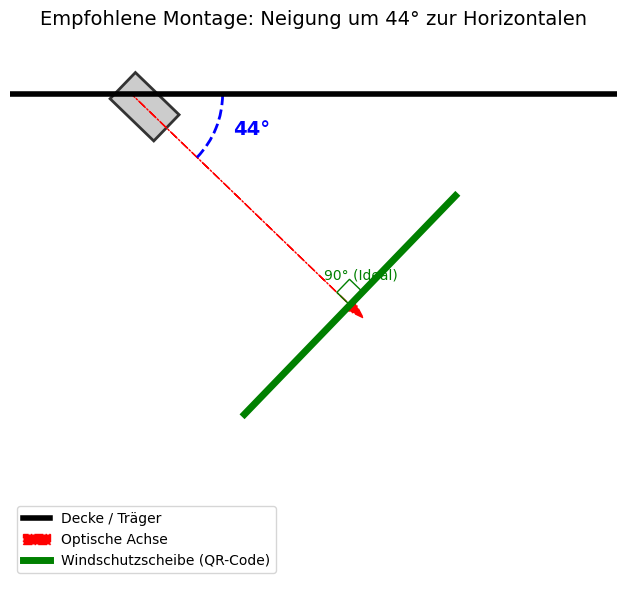

interactive(children=(IntSlider(value=44, description='angle_deg', max=90), Output()), _dom_classes=('widget-i…

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================
# 1. DATENÜBERNAHME
# ==========================================
# Versucht, den berechneten Winkel aus dem vorherigen Analyse-Block zu holen
if 'valid_angles_for_stats' in locals() and len(valid_angles_for_stats) > 0:
    # Median ist robust gegen Ausreißer
    recommended_angle = int(np.median(valid_angles_for_stats))
    print(f"✅ Nutze berechneten Winkel aus Analyse: {recommended_angle}°")
else:
    recommended_angle = 45 # Fallback-Wert
    print(f"⚠️ Keine Daten gefunden. Nutze Standardwert: {recommended_angle}°")

# ==========================================
# 2. VISUALISIERUNG
# ==========================================
def visualize_montage(angle_deg=45):
    """
    Erstellt eine schematische Seitenansicht der Kamera-Montage.
    Zeigt die Neigung der Kamera relativ zur Decke/Horizontalen.
    """
    # Setup der Zeichenfläche
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Geometrische Konstanten für das Schema
    mount_height = 8       # Höhe der Decke
    pivot_x, pivot_y = 2, 8 # Aufhängungspunkt der Kamera
    ray_length = 5         # Länge des Sichtstrahls
    
    # Umrechnung in Bogenmaß (Negativ, da Drehung im Uhrzeigersinn)
    theta_rad = np.radians(angle_deg)
    direction_rad = -theta_rad 
    
    # --- A. Umgebung zeichnen ---
    # Decke / Montageebene
    ax.plot([0, 10], [mount_height, mount_height], 'k-', linewidth=4, label="Decke / Träger")
    
    # --- B. Kamera (Schematisch) ---
    # Definition der Kamera-Box vor der Rotation
    cam_w, cam_h = 1.0, 0.6
    # Rechteck erstellen
    rect = patches.Rectangle((pivot_x - 0.2, pivot_y - cam_h/2), cam_w, cam_h, 
                             linewidth=2, edgecolor='#333333', facecolor='#CCCCCC')
    
    # Transformation: Rotation um den Aufhängungspunkt (pivot)
    t = patches.transforms.Affine2D().rotate_deg_around(pivot_x, pivot_y, -angle_deg) + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)
    
    # --- C. Optische Achse (Blickrichtung) ---
    end_x = pivot_x + ray_length * np.cos(direction_rad)
    end_y = pivot_y + ray_length * np.sin(direction_rad)
    
    ax.arrow(pivot_x, pivot_y, end_x - pivot_x, end_y - pivot_y, 
             head_width=0.2, head_length=0.3, fc='red', ec='red', linestyle='-.', label="Optische Achse")

    # --- D. Zielobjekt (Simulierte Oberfläche) ---
    # Die Oberfläche steht im Idealfall 90° zur optischen Achse
    surf_len = 2.5
    surf_dx = surf_len * np.cos(direction_rad + np.pi/2)
    surf_dy = surf_len * np.sin(direction_rad + np.pi/2)
    
    # Zeichnen der Oberfläche (z.B. Windschutzscheibe)
    ax.plot([end_x - surf_dx, end_x + surf_dx], 
            [end_y - surf_dy, end_y + surf_dy], 
            color='green', linewidth=5, label="QR-Code Ebene (90°)")
    
    # --- E. Annotationen ---
    # Winkelbogen einzeichnen
    arc = patches.Arc((pivot_x, pivot_y), 3, 3, angle=0, theta1=-angle_deg, theta2=0, 
                      color='blue', linewidth=2, linestyle='--')
    ax.add_patch(arc)
    
    # Winkel-Text positionieren
    text_angle = -theta_rad / 2
    ax.text(pivot_x + 1.8 * np.cos(text_angle), pivot_y + 1.8 * np.sin(text_angle), 
            f"{angle_deg}°", fontsize=14, color='blue', fontweight='bold')

    # Rechter Winkel Symbol am Ziel
    marker_size = 0.3
    v_back_x = -np.cos(direction_rad) * marker_size
    v_back_y = -np.sin(direction_rad) * marker_size
    v_surf_x = np.cos(direction_rad + np.pi/2) * marker_size
    v_surf_y = np.sin(direction_rad + np.pi/2) * marker_size
    
    p1 = (end_x, end_y)
    p2 = (end_x + v_back_x, end_y + v_back_y)
    p3 = (end_x + v_back_x + v_surf_x, end_y + v_back_y + v_surf_y)
    p4 = (end_x + v_surf_x, end_y + v_surf_y)
    
    poly = plt.Polygon([p1, p2, p3, p4], closed=True, fill=False, edgecolor='green')
    ax.add_patch(poly)
    ax.text(end_x + v_back_x*2, end_y + v_back_y*2, "90° (Ideal)", fontsize=10, color='green')

    # Achsen-Formatierung
    ax.set_aspect('equal')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 9)
    ax.set_title(f"Montage-Empfehlung: {angle_deg}° Neigung", fontsize=14)
    ax.legend(loc='lower left')
    ax.axis('off') # Koordinatenachsen ausblenden
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. AUSFÜHRUNG
# ==========================================
# Versuch, Interaktivität zu laden, sonst statische Anzeige
try:
    import ipywidgets as widgets
    print("ℹ️  Interaktiver Modus aktiviert.")
    widgets.interact(visualize_montage, angle_deg=widgets.IntSlider(min=0, max=90, step=1, value=recommended_angle, description='Winkel:'))
except ImportError:
    print("ℹ️  ipywidgets nicht installiert. Zeige statisches Bild.")
    visualize_montage(recommended_angle)